In [ ]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
!rm -rf Face-Mask-Detection-master
!rm -f master.zip

In [ ]:
!wget https://github.com/chandrikadeb7/Face-Mask-Detection/archive/refs/heads/master.zip

--2026-03-02 14:15:31--  https://github.com/chandrikadeb7/Face-Mask-Detection/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/chandrikadeb7/Face-Mask-Detection/zip/refs/heads/master [following]
--2026-03-02 14:15:31--  https://codeload.github.com/chandrikadeb7/Face-Mask-Detection/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.114.9
Connecting to codeload.github.com (codeload.github.com)|140.82.114.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [  <=>               ] 190.46M  25.3MB/s    in 7.5s    

2026-03-02 14:15:39 (25.5 MB/s) - ‘master.zip’ saved [199714088]



In [ ]:
!unzip master.zip

Archive:  master.zip
7e500749401bad4bb338790fbdb89b58e41ef2d9
   creating: Face-Mask-Detection-master/
  inflating: Face-Mask-Detection-master/.DS_Store  
   creating: Face-Mask-Detection-master/.github/
  inflating: Face-Mask-Detection-master/.github/FUNDING.yml  
   creating: Face-Mask-Detection-master/.github/ISSUE_TEMPLATE/
  inflating: Face-Mask-Detection-master/.github/ISSUE_TEMPLATE/bug.md  
  inflating: Face-Mask-Detection-master/.github/ISSUE_TEMPLATE/documentation.md  
  inflating: Face-Mask-Detection-master/.github/ISSUE_TEMPLATE/feature.md  
  inflating: Face-Mask-Detection-master/.github/ISSUE_TEMPLATE/proposal.md  
  inflating: Face-Mask-Detection-master/.github/auto_assign.yml  
  inflating: Face-Mask-Detection-master/.github/config.yml  
  inflating: Face-Mask-Detection-master/.github/pull_request_template.md  
   creating: Face-Mask-Detection-master/.github/workflows/
  inflating: Face-Mask-Detection-master/.github/workflows/action.yml  
  inflating: Face-Mask-Detectio

In [ ]:
!ls Face-Mask-Detection-master/dataset

with_mask  without_mask


In [ ]:
data_dir = "Face-Mask-Detection-master/dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    color_mode='rgb'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    color_mode='rgb'
)

Found 3274 images belonging to 2 classes.
Found 818 images belonging to 2 classes.


In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Ready")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Ready


In [ ]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 65/103 ━━━━━━━━━━━━━━━━━━━━ 2:24 4s/step - accuracy: 0.6642 - loss: 1.8349

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


103/103 ━━━━━━━━━━━━━━━━━━━━ 408s 4s/step - accuracy: 0.7170 - loss: 1.4149 - val_accuracy: 0.9205 - val_loss: 0.2127
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 388s 4s/step - accuracy: 0.8935 - loss: 0.2769 - val_accuracy: 0.9144 - val_loss: 0.2559
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 378s 4s/step - accuracy: 0.8970 - loss: 0.2523 - val_accuracy: 0.9389 - val_loss: 0.1780
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 395s 4s/step - accuracy: 0.9187 - loss: 0.2053 - val_accuracy: 0.9511 - val_loss: 0.1575
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 411s 4s/step - accuracy: 0.9217 - loss: 0.1984 - val_accuracy: 0.9523 - val_loss: 0.1210
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 396s 4s/step - accuracy: 0.9375 - loss: 0.1643 - val_accuracy: 0.9572 - val_loss: 0.1175
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.9295 - loss: 0.1717 - val_accuracy: 0.9389 - val_loss: 0.1469
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 456s 4s/step - accuracy: 0.9439 - loss: 0.1503 - val_accuracy: 0.947

In [ ]:
train_data.class_indices

{'with_mask': 0, 'without_mask': 1}

In [ ]:
model.save("face_mask_model.h5")

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving images.jpg to images.jpg
Saving download (1).jpg to download (1).jpg
Saving download.jpg to download.jpg
Saving No_Mask3.jpg to No_Mask3.jpg
Saving No_Mask2.jpg to No_Mask2.jpg
Saving No_Mask1.jpg to No_Mask1.jpg
Saving No_Mask.jpg to No_Mask.jpg
Saving MAsk_4.jpg to MAsk_4.jpg
Saving Mask_1.jpg to Mask_1.jpg
Saving Mask.jpg to Mask.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


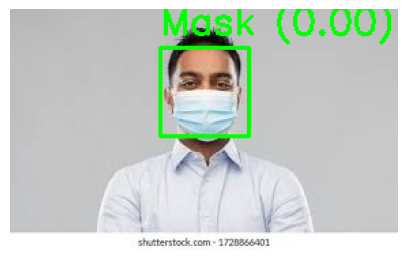

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


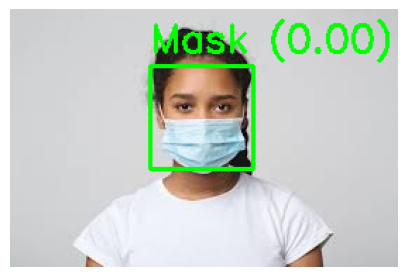

No face detected


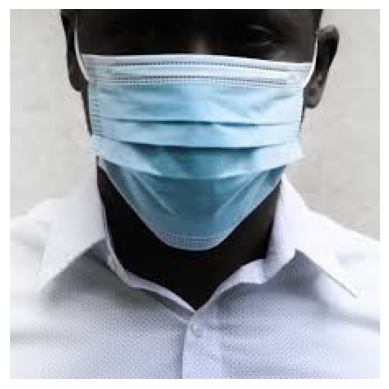

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


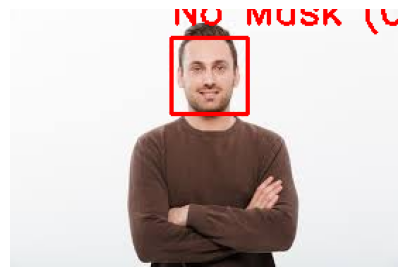

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


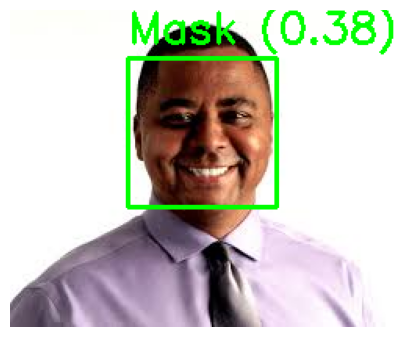

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


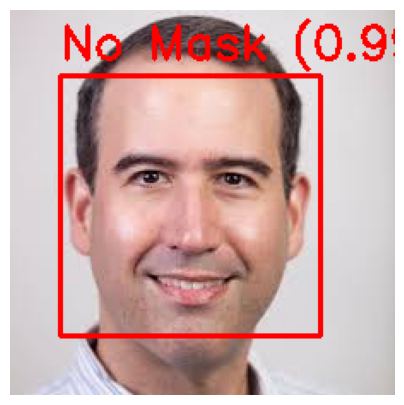

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


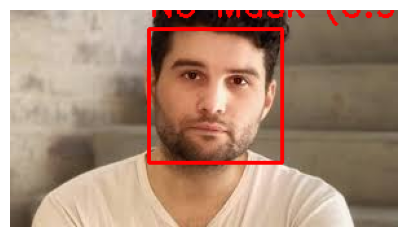

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


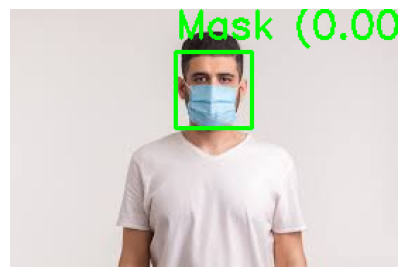

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


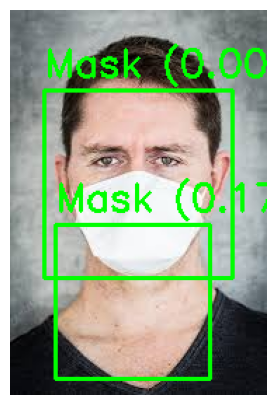

No face detected


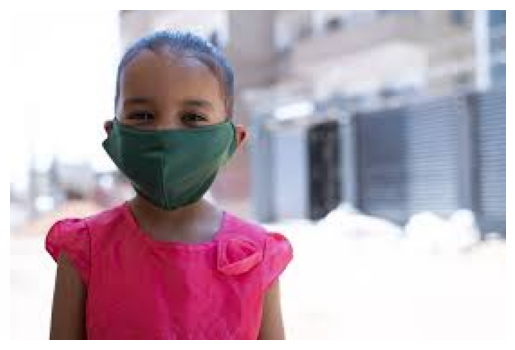

In [ ]:
for img_name in uploaded.keys():


    img = cv2.imread(img_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(30,30)
    )

    if len(faces) == 0:
        print("No face detected")
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.show()
        continue

    for (x,y,w,h) in faces:

        face = img_rgb[y:y+h, x:x+w]
        face = cv2.resize(face,(224,224))
        face = face/255.0
        face = np.reshape(face,(1,224,224,3))

        pred = model.predict(face)

        confidence = pred[0][0]
        label = "No Mask" if confidence > 0.5 else "Mask"
        color = (0,255,0) if label=="Mask" else (255,0,0)

        text = f"{label} ({confidence:.2f})"

        cv2.rectangle(img_rgb,(x,y),(x+w,y+h),color,2)
        cv2.putText(img_rgb,text,(x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,0.9,color,2)

    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()